# Merge and rename UT SVI Files
Current UT SVI files have input variables and SVI ranks in different files.
This notebook merges the files and renames the variables to match the SVI.

## Description of Program
- program:    tu3svi2_2av3_MergeUT
- task:       Clean UT SVI Files from Matt Preisser
- Version:    2023-11-09
- 2023-11-29: Add quartile SVI
- 2024-03-26: updated SVI from Matt, fixed data issues
- 2024-04-03: Minor edits - fixed SVI to be percentile.
- 2024-04-04: Updated data from Matt Preisser
- 2024-08-26: Update for new format and for 2020 data
- 2024-09-20: Rerun so that SVI have consistent number of significant digits
- 2025-04-08: Found error in fixing issue with how percentile rank is adjusted 
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 2 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  0.14.2


In [3]:
# Add the folder above the current notebook directory to the Python path
sys.path.append('../')

# Import the script as a module
import tu3svi2_0bv1_sourcedatautility_20240906 as my_utility

## Set Provenance 

In [4]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\DesignSafe-Archive\\SourceData\\UT_Preisser_SVI'

In [5]:
# Store Program Name for output files to have the same name and saved in the same directory
programname = "tu3svi2_2av3_SetupUT_2025-04-08"
# Make directory to save output
#if not os.path.exists(programname):
#   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [6]:
# read in excel file
# Read in sheet with all metadata on each variable
varmetadata_df = pd.read_excel("../tu3svi2_0av3_SVIdatadictionary_2025-04-08.xlsx",
                            sheet_name="SVI_vars")
varmetadata_df[(varmetadata_df['SVI']=='UTP')].head()

,SVI,order,year,newvarname,gencat,gencatcode,comcat,comcatcode,theme,SVIcat,label,oldvarname,ACStable1v2,ACStable1v1,inverted,proportion,percent,dtype
54,UTP,10010,2018,U201810010,Geocode,100,TRACT2010,10,NaN,Geocode,Census Tract 11 Digit Geocode,GEOID_Tract,NaN,NaN,0,0,0,str
55,UTP,10011,2018,U201810011,Geocode,100,BG2010,11,NaN,Geocode,Census Block Group 12 Digit Geocode,GEOID_BG,NaN,NaN,0,0,0,str
56,UTP,20010,2018,U201820010,Economic,200,Poverty,10,NaN,Social status,Percent Poverty,QPOVTY,B17021,B17026,0,1,0,float
57,UTP,20013,2018,U201820013,Economic,200,NaN,13,NaN,Elderly,Households with Social Security Income,QSSBEN,B19055,B19055,0,1,0,float
58,UTP,20020,2018,U201820020,Economic,200,Unemployed,20,NaN,Social status,Civil Unemployment Over 16 Years,QCVLUN,B23025,B23025,0,1,0,float


In [7]:
data_year = 2020
data_year_str = str(data_year)
svi_name = 'UTP'
svi_folder = 'Preisser_SV_Data_2024-08-26'
tx_folder = 'Texas/SVIs'
geoscales = ['Tract', 'BG']  # census tract and block group
files = {  'BG' : {'folder' : f'{svi_folder}/{tx_folder}', 
                                'inputvars' : f'Texas_{data_year_str}_bg_SVI_svi.csv'
                                },
            'Tract' : {'folder' : f'{svi_folder}/{tx_folder}', 
                        'inputvars' : f'Texas_{data_year_str}_tract_SVI_svi.csv'
                        },
            } 

### Merge plan
2. Merge tract SETX and TX files

This will go from 8 files to 2 files. The TX and SETX have the same input variables but will have different SVI ranks.

In [8]:
dfs = {}
for file in files:
    # Set path to folder containing the files to be merged
    file_folder = files[file]['folder']
    # Set path to input variables file
    file_name = files[file]['inputvars']
    # make full path
    file_path = os.path.join(file_folder, file_name)

    dfs[file] = pd.read_csv(file_path, dtype={'index' : str})

In [9]:
dfs['Tract'].head()  

,index,key_0,geometry,MDGRENT,MDHSEVAL,MEDAGE,PERCAP,PPUNIT,QAGEDEP,QASIAN,...,F3: 2,F3: 3,F3: 4,F3: 5,FA_SVI_Unscaled,FA_SVI_Scaled,FA_SVI_Rank,FA_SVI_Percentile,RM_SVI_Rank,RM_SVI_Percentile
0,48215020507,48215020507,"POLYGON ((-98.267506 26.170298, -98.267069 26....",581.000000,-49200.000000,24.5,-11275.0,3.51,0.907536,0.000000,...,0.019514,0.265418,0.259267,0.066822,1.760327,1.000000,1.0,1.000000,794.0,0.883810
1,48261950100,48261950100,"MULTIPOLYGON (((-97.398388 26.867894, -97.3913...",529.909091,-89735.868421,41.2,-15058.0,2.99,0.971867,0.002558,...,0.017561,0.412963,0.086718,-0.120856,1.571572,0.950791,2.0,0.999853,1401.0,0.794872
2,48441012100,48441012100,"POLYGON ((-99.725101 32.423301, -99.70952 32.4...",768.148148,-113760.917431,51.2,-12527.0,2.17,1.050909,0.000000,...,0.376888,0.451271,0.831701,0.014051,1.525457,0.938769,3.0,0.999707,4222.0,0.381538
3,48061012103,48061012103,"POLYGON ((-97.676183 26.140106, -97.672638 26....",831.066946,-16500.000000,78.6,-19709.0,1.54,1.530612,0.000000,...,0.411256,1.155635,0.379172,-0.151546,1.491041,0.929797,4.0,0.999560,4422.0,0.352234
4,48377950200,48377950200,"POLYGON ((-104.547791 29.714414, -104.544815 2...",390.000000,-50400.000000,42.5,-9916.0,2.73,0.902073,0.029783,...,0.057234,0.285728,0.206286,-0.104022,1.464013,0.922750,5.0,0.999414,11.0,0.998535


In [10]:
dfs['BG'].head()  

,index,key_0,geometry,MDGRENT,MDHSEVAL,MEDAGE,PERCAP,PPUNIT,QAGEDEP,QASIAN,...,F2: 2,F2: 3,F2: 4,F2: 5,FA_SVI_Unscaled,FA_SVI_Scaled,FA_SVI_Rank,FA_SVI_Percentile,RM_SVI_Rank,RM_SVI_Percentile
0,484790019003,484790019003,"POLYGON ((-99.510339 27.509895, -99.503224 27....",236.000000,-71328.981013,78.3,-9939.0,1.04,1.202247,0.000000,...,-0.024245,0.861948,-0.144898,0.531915,2.277627,1.000000,1.0,1.000000,616.0,0.966609
1,481130166351,481130166351,"POLYGON ((-96.878458 32.642901, -96.874241 32....",792.000000,-208910.712871,74.1,-16472.0,1.12,1.769663,0.000000,...,0.144925,0.748602,0.722978,0.407487,1.967495,0.930048,2.0,0.999946,3777.0,0.794983
2,480610140012,480610140012,"POLYGON ((-97.505285 25.902682, -97.499639 25....",270.000000,-49878.530120,53.4,-8749.0,1.59,1.037755,0.000000,...,-0.035348,0.473423,0.076991,0.414258,1.964055,0.929272,3.0,0.999891,1119.0,0.939299
3,481130162031,481130162031,"POLYGON ((-97.015374 32.71341, -97.012161 32.7...",973.366071,-133834.233083,50.0,-15051.0,1.10,1.172414,0.047745,...,-0.183872,0.348174,0.410665,0.466679,1.935211,0.922766,4.0,0.999837,182.0,0.990173
4,482150205072,482150205072,"POLYGON ((-98.260053 26.165923, -98.252051 26....",1011.737374,-87253.160622,57.0,-0.0,2.02,1.031802,0.000000,...,0.033919,0.469078,0.339583,0.005871,1.907331,0.916477,5.0,0.999783,2409.5,0.869231


In [11]:
# rename GEOID GEOID_Tract
dfs['Tract'] = dfs['Tract'].rename(columns={'index' : 'GEOID20_Tract'})
# rename GEOID GEOID_Tract
dfs['BG'] = dfs['BG'].rename(columns={'index' : 'GEOID20_BG'})

In [12]:
dfs['Tract'].head(1)

,GEOID20_Tract,key_0,geometry,MDGRENT,MDHSEVAL,MEDAGE,PERCAP,PPUNIT,QAGEDEP,QASIAN,...,F3: 2,F3: 3,F3: 4,F3: 5,FA_SVI_Unscaled,FA_SVI_Scaled,FA_SVI_Rank,FA_SVI_Percentile,RM_SVI_Rank,RM_SVI_Percentile
0,48215020507,48215020507,"POLYGON ((-98.267506 26.170298, -98.267069 26....",581.0,-49200.0,24.5,-11275.0,3.51,0.907536,0.0,...,0.019514,0.265418,0.259267,0.066822,1.760327,1.0,1.0,1.0,794.0,0.88381


In [13]:
dfs['BG'].head(1)

,GEOID20_BG,key_0,geometry,MDGRENT,MDHSEVAL,MEDAGE,PERCAP,PPUNIT,QAGEDEP,QASIAN,...,F2: 2,F2: 3,F2: 4,F2: 5,FA_SVI_Unscaled,FA_SVI_Scaled,FA_SVI_Rank,FA_SVI_Percentile,RM_SVI_Rank,RM_SVI_Percentile
0,484790019003,484790019003,"POLYGON ((-99.510339 27.509895, -99.503224 27....",236.0,-71328.981013,78.3,-9939.0,1.04,1.202247,0.0,...,-0.024245,0.861948,-0.144898,0.531915,2.277627,1.0,1.0,1.0,616.0,0.966609


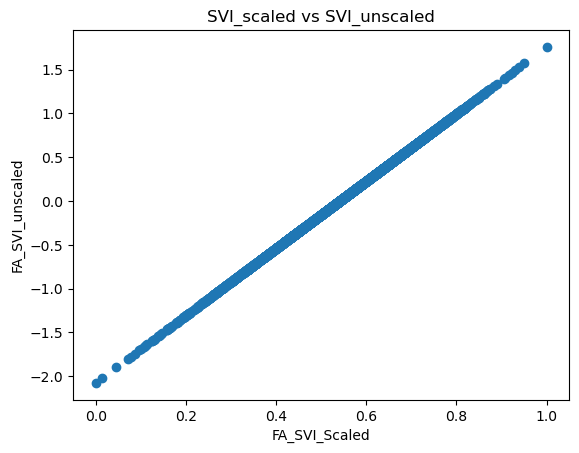

In [14]:
# run a scatter plot of FA_SVI_scaled vs SVI_unscaled
import matplotlib.pyplot as plt
plt.scatter(dfs['Tract']['FA_SVI_Scaled'], dfs['Tract']['FA_SVI_Unscaled'])
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('FA_SVI_unscaled')
plt.title('SVI_scaled vs SVI_unscaled')
plt.show()

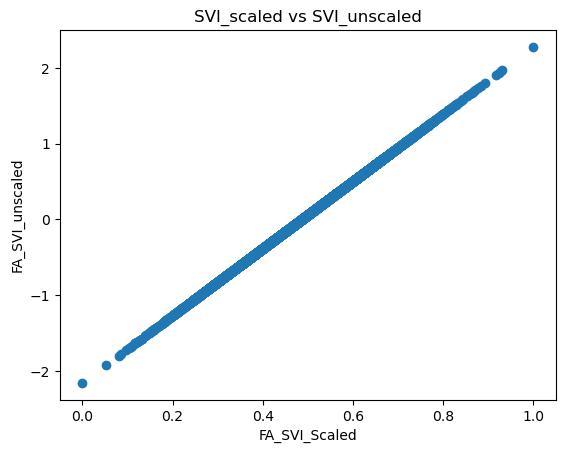

In [15]:
# run a scatter plot of FA_SVI_scaled vs SVI_unscaled
import matplotlib.pyplot as plt
plt.scatter(dfs['BG']['FA_SVI_Scaled'], dfs['BG']['FA_SVI_Unscaled'])
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('FA_SVI_unscaled')
plt.title('SVI_scaled vs SVI_unscaled')
plt.show()

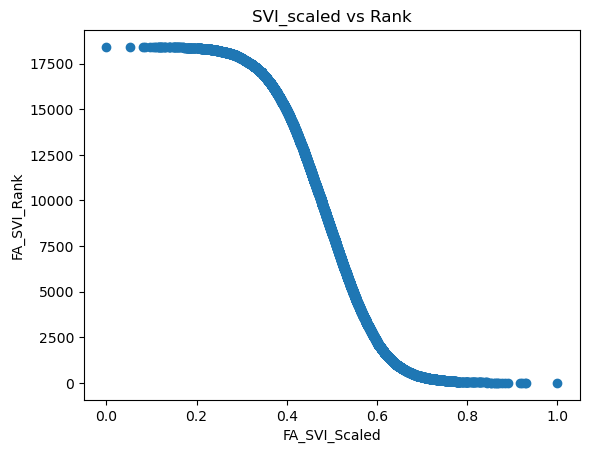

In [16]:
plt.scatter(dfs['BG']['FA_SVI_Scaled'], dfs['BG']['FA_SVI_Rank'])
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('FA_SVI_Rank')
plt.title('SVI_scaled vs Rank')
plt.show()

### Add SVI quartiles

In [17]:
dfs['Tract']['FA_SVI_Scaled_v2'] = dfs['Tract']['FA_SVI_Scaled'].rank(pct=True)

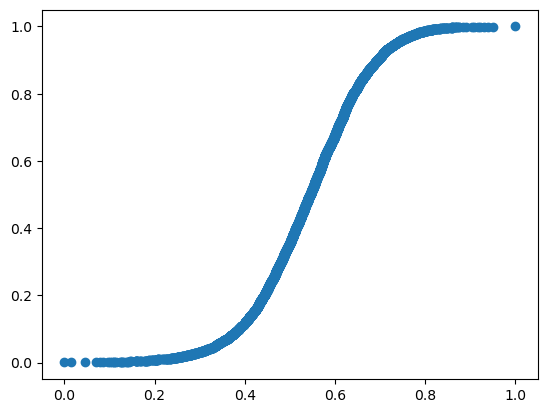

In [18]:
# compare the two
plt.scatter(dfs['Tract']['FA_SVI_Scaled'], dfs['Tract']['FA_SVI_Scaled_v2'])

In [19]:
dfs['Tract'][['FA_SVI_Scaled', 'FA_SVI_Scaled_v2']].describe().T

,count,mean,std,min,25%,50%,75%,max
FA_SVI_Scaled,6825.0,0.541078,0.122501,0.000000,0.462627,0.545038,0.623015,1.0
FA_SVI_Scaled_v2,6825.0,0.500073,0.288696,0.000147,0.250110,0.500073,0.750037,1.0


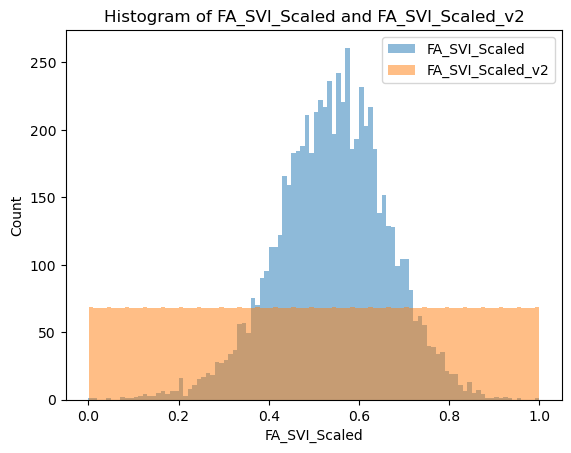

In [20]:
# histogram of FA_SVI_Scaled and FA_SVI_Scaled_v2
plt.hist(dfs['Tract']['FA_SVI_Scaled'], bins=100, alpha=0.5, label='FA_SVI_Scaled')
plt.hist(dfs['Tract']['FA_SVI_Scaled_v2'], bins=100, alpha=0.5, label='FA_SVI_Scaled_v2')
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('Count')
plt.title('Histogram of FA_SVI_Scaled and FA_SVI_Scaled_v2')
plt.legend()
plt.show()

In [21]:
for file in ['BG','Tract']:
    # need to convert SVI_scaled to percentile rank
    dfs[file]['FA_SVI_Scaled_v2'] = dfs[file]['FA_SVI_Scaled'].rank(pct=True)

    dfs[file] = my_utility.quartileSVI(dfs[file], 'FA_SVI_Scaled_v2', 'FA_SVI_Scaled_v2')

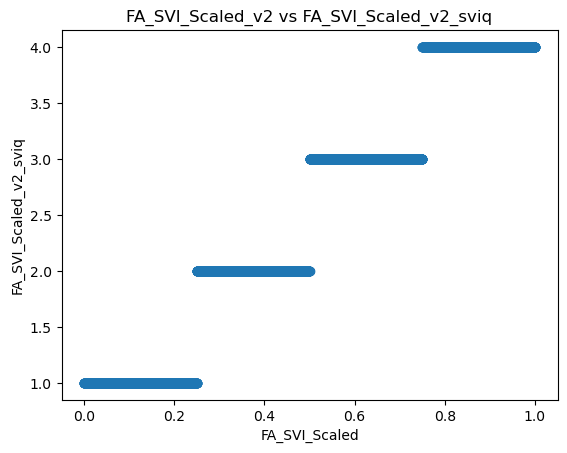

In [22]:
# run a scatter plot of FA_SVI_scaled vs SVI_unscaled
import matplotlib.pyplot as plt
plt.scatter(dfs['Tract']['FA_SVI_Scaled_v2'], dfs['Tract']['FA_SVI_Scaled_v2_sviq'])
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('FA_SVI_Scaled_v2_sviq')
plt.title('FA_SVI_Scaled_v2 vs FA_SVI_Scaled_v2_sviq')
plt.show()

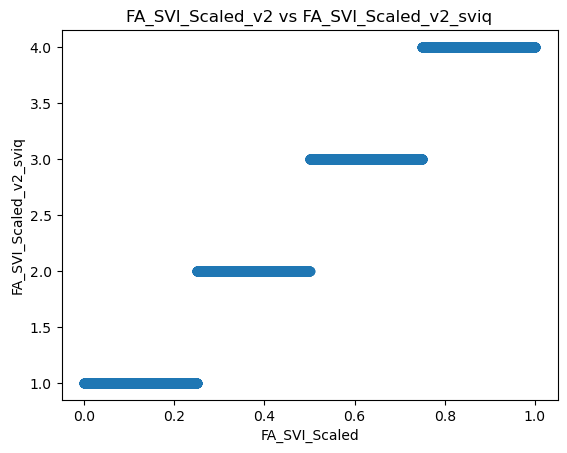

In [23]:
# run a scatter plot of FA_SVI_scaled vs SVI_unscaled
import matplotlib.pyplot as plt
plt.scatter(dfs['BG']['FA_SVI_Scaled_v2'], dfs['BG']['FA_SVI_Scaled_v2_sviq'])
plt.xlabel('FA_SVI_Scaled')
plt.ylabel('FA_SVI_Scaled_v2_sviq')
plt.title('FA_SVI_Scaled_v2 vs FA_SVI_Scaled_v2_sviq')
plt.show()

# Rename variables
Using the Variable Data Dictionary Excel Sheet rename the variables to match across SVI.

In [24]:
varmetadata_df.head(1)

,SVI,order,year,newvarname,gencat,gencatcode,comcat,comcatcode,theme,SVIcat,label,oldvarname,ACStable1v2,ACStable1v1,inverted,proportion,percent,dtype
0,CDC,10010,2018,C201810010,Geocode,100,TRACT2010,10,NaN,Geocode,Census Tract 11 Digit Geocode,FIPS,NaN,NaN,0,0,0,str


In [25]:
geoscales

['Tract', 'BG']

In [26]:
cleaned_files = my_utility.update_varnames(varmetadata_df= varmetadata_df,
                    svi_name = svi_name,
                    data_year = data_year,
                    merge_by_geo = dfs, # dataframes with svi data
                    geoscales = geoscales,
                    programname = programname)

Current variable name:  GEOID20_Tract
Found variable in variable dictionary
Then new variable name is:  TRACT2020 check length:  9
renaming GEOID20_Tract to TRACT2020
Current variable name:  GEOID20_BG
Found variable in variable dictionary
Then new variable name is:  BG2020 check length:  6
Could not find GEOID20_BG in dataframe
Current variable name:  QPOVTY
Found variable in variable dictionary
Then new variable name is:  U202020010 check length:  10
renaming QPOVTY to U202020010
Current variable name:  QSSBEN
Found variable in variable dictionary
Then new variable name is:  U202020013 check length:  10
renaming QSSBEN to U202020013
Current variable name:  QCVLUN
Found variable in variable dictionary
Then new variable name is:  U202020020 check length:  10
renaming QCVLUN to U202020020
Current variable name:  PERCAP
Found variable in variable dictionary
Then new variable name is:  U202020031 check length:  10
renaming PERCAP to U202020031
Current variable name:  QRICH
Found variable 

Current variable name:  QESL
Found variable in variable dictionary
Then new variable name is:  U202062010 check length:  10
renaming QESL to U202062010
Current variable name:  QFEMALE
Found variable in variable dictionary
Then new variable name is:  U202065010 check length:  10
renaming QFEMALE to U202065010
Current variable name:  QFHH
Found variable in variable dictionary
Then new variable name is:  U202065015 check length:  10
renaming QFHH to U202065015
Current variable name:  QFEMLBR
Found variable in variable dictionary
Then new variable name is:  U202065017 check length:  10
renaming QFEMLBR to U202065017
Current variable name:  QMOHO
Found variable in variable dictionary
Then new variable name is:  U202070010 check length:  10
renaming QMOHO to U202070010
Current variable name:  QUNOCCHU
Found variable in variable dictionary
Then new variable name is:  U202070030 check length:  10
renaming QUNOCCHU to U202070030
Current variable name:  QRENTER
Found variable in variable diction

In [27]:
cleaned_files['Tract'].head()

,TRACT2020,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,U202021010,U202030020,...,U202065017,U202070010,U202070030,U202070040,U202070060,U202072010,U202020050,U202081021,U202081022,U202090012
0,48215020507,0.21507,0.67571,0.02937,-11275,-0.0,-49200,581,0.76080,0.90754,...,0.45386,0.00000,0.04502,0.24429,3.51,0.15571,0.30998,0.34191,0.00000,1.00000
1,48261950100,0.02046,0.59690,0.00000,-15058,-0.0,-89735,529,0.78148,0.97187,...,0.35065,0.04977,0.41629,0.79070,2.99,0.00000,0.27366,0.24026,0.09091,0.99985
2,48441012100,0.47159,1.00000,0.01875,-12527,-0.0,-113760,768,0.25287,1.05091,...,0.98089,0.00000,0.00000,0.00000,2.17,0.00000,0.03788,0.01911,0.00000,0.99971
3,48061012103,0.06633,1.00000,0.00000,-19709,-0.0,-16500,831,0.07398,1.53061,...,1.00000,0.95548,0.59618,0.19685,1.54,0.00000,0.00000,0.00000,0.00000,0.99956
4,48377950200,0.52943,0.48701,0.19801,-9916,-0.0,-50400,390,0.64987,0.90207,...,0.52775,0.21048,0.37903,0.56299,2.73,0.05974,0.28330,0.13256,0.03894,0.99941


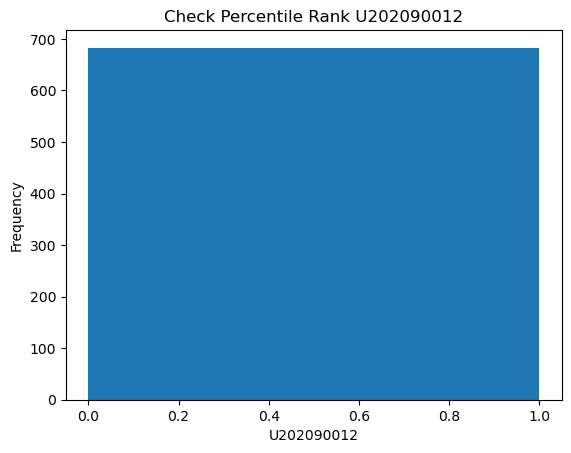

In [28]:
# make a histogram of SVI_scaled
plt.hist(cleaned_files['Tract'][f'U{data_year_str}90012'])
plt.xlabel(f'U{data_year_str}90012')
plt.ylabel('Frequency')
plt.title(f'Check Percentile Rank U{data_year_str}90012')
plt.show()

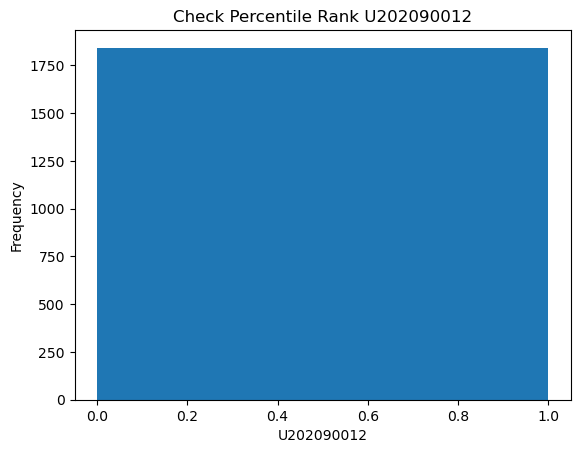

In [29]:
# make a histogram of SVI_scaled
plt.hist(cleaned_files['BG'][f'U{data_year_str}90012'])
plt.xlabel(f'U{data_year_str}90012')
plt.ylabel('Frequency')
plt.title(f'Check Percentile Rank U{data_year_str}90012')
plt.show()

In [30]:
cleaned_files['BG'].head()

,BG2020,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,U202021010,U202030020,...,U202065017,U202070010,U202070030,U202070040,U202070060,U202072010,U202020050,U202081021,U202081022,U202090012
0,484790019003,0.79026,0.83621,0.18750,-9939,-0.0,-71328,236,0.77470,1.20225,...,0.00000,0.0,0.35376,1.00000,1.04,0.79310,0.31692,0.53846,0.00000,1.00000
1,481130166351,0.32397,0.85294,0.45000,-16472,-0.0,-208910,792,0.14419,1.76966,...,1.00000,0.0,0.05179,1.00000,1.12,0.41597,0.19879,0.00000,0.00000,0.99995
2,480610140012,0.72041,0.64715,0.00000,-8749,-0.0,-49878,270,0.74402,1.03776,...,0.45635,0.0,0.04206,0.95285,1.59,0.66829,0.22415,0.52381,0.12302,0.99989
3,481130162031,0.48011,0.42690,0.50242,-15051,-0.0,-133834,973,0.56322,1.17241,...,0.27184,0.0,0.10236,1.00000,1.10,0.86550,0.27012,0.33981,0.00000,0.99984
4,482150205072,0.86572,0.72857,0.00000,0,-0.0,-87253,1011,0.80000,1.03180,...,1.00000,0.0,0.00000,0.00000,2.02,0.00000,0.30998,0.00000,0.00000,0.99978
